# Used Car Price Prediction — EDA
I'm starting with some exploratory analysis just to get a feel for the data before jumping into modeling.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# just a personal style preference
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('car_data.csv')
print('Dataset loaded!')

Dataset loaded!


## 1. Load and Inspect

In [3]:
print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape: (301, 9)

First 5 rows:


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
print('Data types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

Data types:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

Missing values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Duplicate rows: 2


**Note:** Got 301 rows and 9 columns. No missing values and no duplicates which is nice — saves some cleaning work.

## 2. Target Variable — Selling Price

count    301.000000
mean       4.661296
std        5.082812
min        0.100000
25%        0.900000
50%        3.600000
75%        6.000000
max       35.000000
Name: Selling_Price, dtype: float64


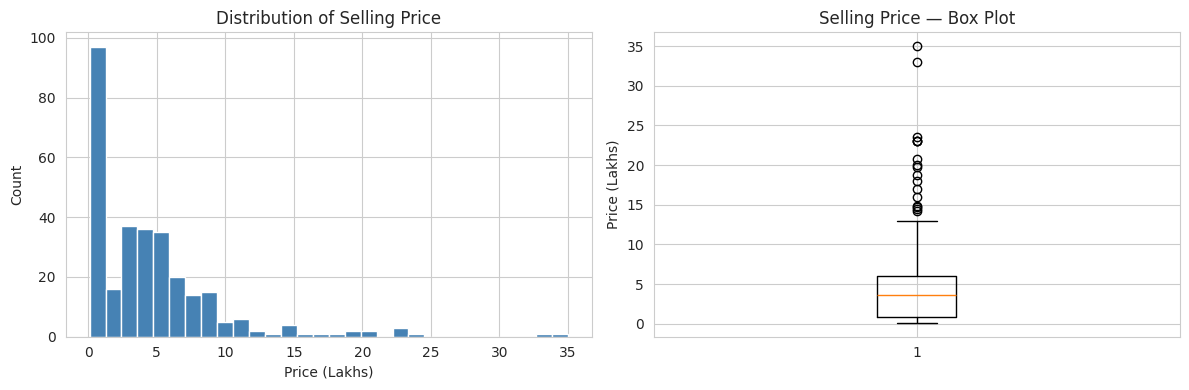

In [5]:
print(df['Selling_Price'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Selling_Price'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Selling Price')
axes[0].set_xlabel('Price (Lakhs)')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['Selling_Price'], vert=True)
axes[1].set_title('Selling Price — Box Plot')
axes[1].set_ylabel('Price (Lakhs)')

plt.tight_layout()
plt.show()

**What I see:** The price distribution is pretty skewed to the right. Most cars are listed under 10 lakhs, but a handful go all the way up to 35. The mean is around 4.66 and median is 3.6, so that gap tells me there are some high-price cars pulling the average up.

## 3. Correlation Analysis

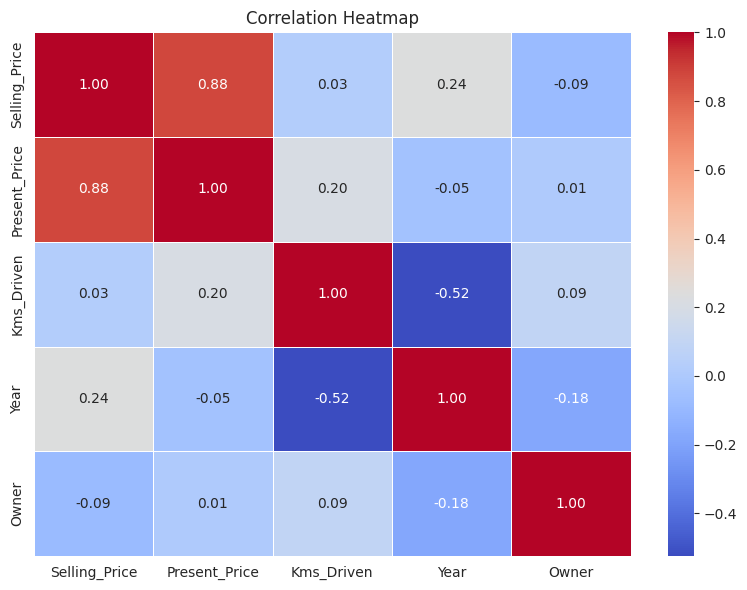


Correlation with Selling_Price:
Selling_Price    1.000000
Present_Price    0.878983
Year             0.236141
Kms_Driven       0.029187
Owner           -0.088344
Name: Selling_Price, dtype: float64


In [6]:
num_cols = ['Selling_Price', 'Present_Price', 'Kms_Driven', 'Year', 'Owner']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print('\nCorrelation with Selling_Price:')
print(corr['Selling_Price'].sort_values(ascending=False))

**What I see:** Present_Price and Selling_Price are strongly correlated (0.88) — makes sense, a newer/expensive car is still worth more used. Year is also positive, newer the car the higher the price. Kms_Driven is slightly negative which is expected. Owner barely shows any correlation at all.

## 4. Relationship Plots

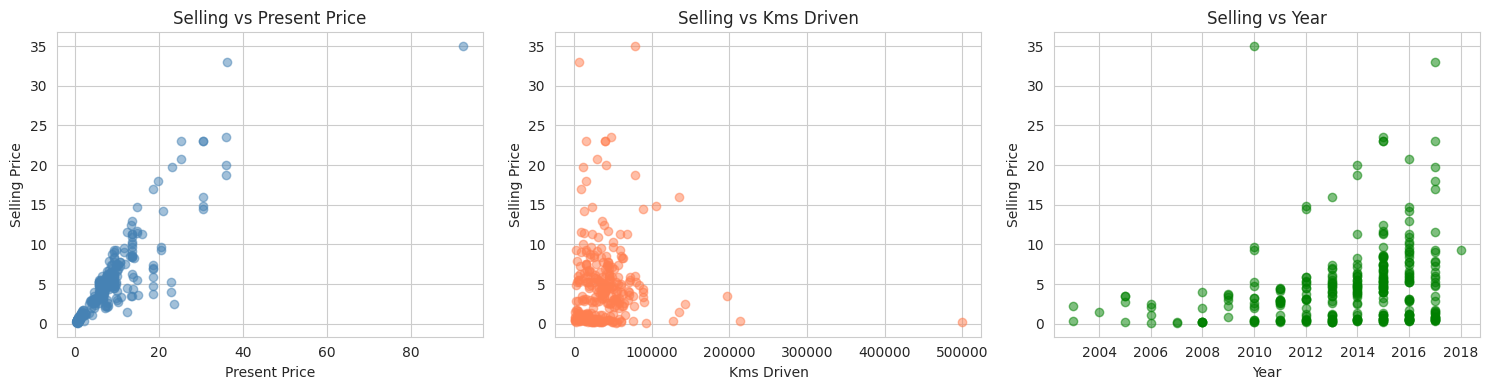

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df['Present_Price'], df['Selling_Price'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('Present Price')
axes[0].set_ylabel('Selling Price')
axes[0].set_title('Selling vs Present Price')

axes[1].scatter(df['Kms_Driven'], df['Selling_Price'], alpha=0.5, color='coral')
axes[1].set_xlabel('Kms Driven')
axes[1].set_ylabel('Selling Price')
axes[1].set_title('Selling vs Kms Driven')

axes[2].scatter(df['Year'], df['Selling_Price'], alpha=0.5, color='green')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Selling Price')
axes[2].set_title('Selling vs Year')

plt.tight_layout()
plt.show()

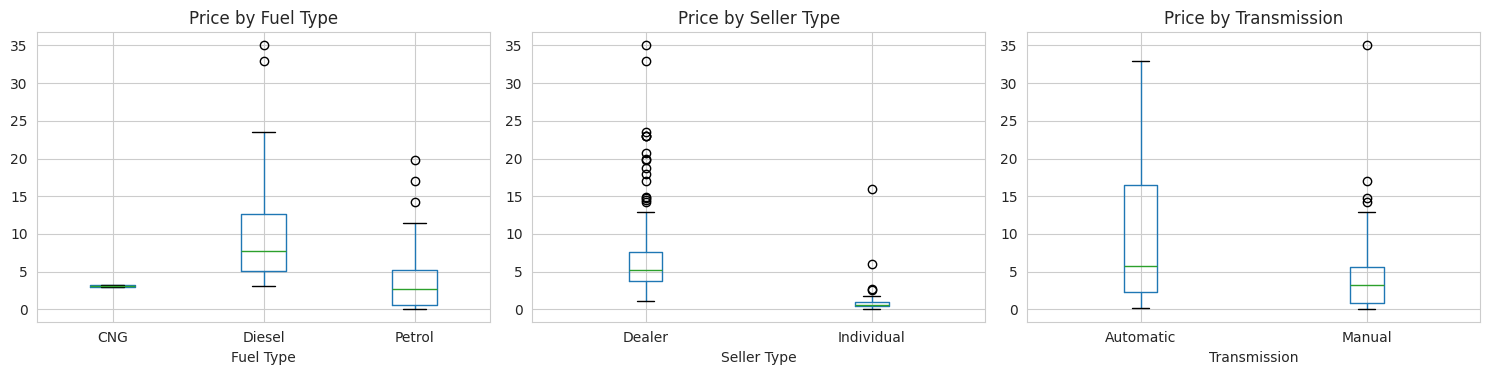

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df.boxplot(column='Selling_Price', by='Fuel_Type', ax=axes[0])
axes[0].set_title('Price by Fuel Type')
axes[0].set_xlabel('Fuel Type')

df.boxplot(column='Selling_Price', by='Seller_Type', ax=axes[1])
axes[1].set_title('Price by Seller Type')
axes[1].set_xlabel('Seller Type')

df.boxplot(column='Selling_Price', by='Transmission', ax=axes[2])
axes[2].set_title('Price by Transmission')
axes[2].set_xlabel('Transmission')

plt.suptitle('')
plt.tight_layout()
plt.show()

**What I noticed:**
- Diesel cars are generally priced a bit higher than Petrol ones
- Dealers seem to list at higher prices compared to individual sellers
- Automatic cars cost more, though there aren't many of them in this dataset (only 40)

## 5. Car Age Analysis

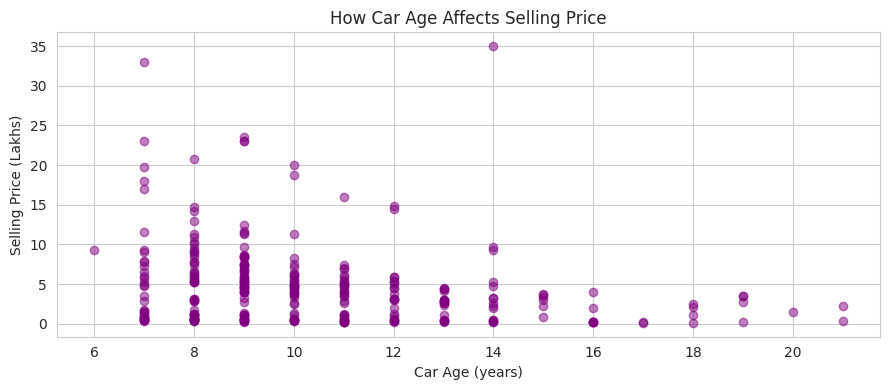

Car_Age
6     9.250000
7     6.209143
8     5.213200
9     5.927049
10    4.762105
11    3.540909
12    3.841304
13    2.375263
14    5.262667
15    2.816667
16    1.002857
17    0.160000
18    1.437500
19    2.487500
20    1.500000
21    1.300000
Name: Selling_Price, dtype: float64


In [9]:
df['Car_Age'] = 2024 - df['Year']

plt.figure(figsize=(9, 4))
plt.scatter(df['Car_Age'], df['Selling_Price'], alpha=0.5, color='purple')
plt.xlabel('Car Age (years)')
plt.ylabel('Selling Price (Lakhs)')
plt.title('How Car Age Affects Selling Price')
plt.tight_layout()
plt.show()

print(df.groupby('Car_Age')['Selling_Price'].mean().sort_index())

**What I see:** Newer cars (smaller age) sell for more — pretty much expected. Once a car hits 10+ years, the price drops a lot. There are a few older cars still priced high, probably some Diesel or premium models.

## 6. Key Findings

Here's what stood out from the analysis:

- **Present_Price** is clearly the most useful feature, 0.88 correlation with selling price
- **Diesel cars** tend to sell higher on average — noticeable from the box plots
- **Car_Age** works better than the raw Year column since it gives the actual age directly
- **Owner** column is almost useless — 290 out of 301 rows are 0, barely any variation
- **Kms_Driven** has one weird outlier at 500,000 km — need to handle that before training
- **Car_Name** has too many unique values to be useful, will just drop it

**Plan for preprocessing:**
- Create Car_Age from Year, then drop Year and Car_Name
- One-hot encode the three categorical columns (Fuel_Type, Seller_Type, Transmission)
- Cap Kms_Driven outlier at 200,000 km